## **Generando sólo el outfit sin ponerselo al dueño del armario**

In [ ]:
!pip install huggingface_hub Pillow

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


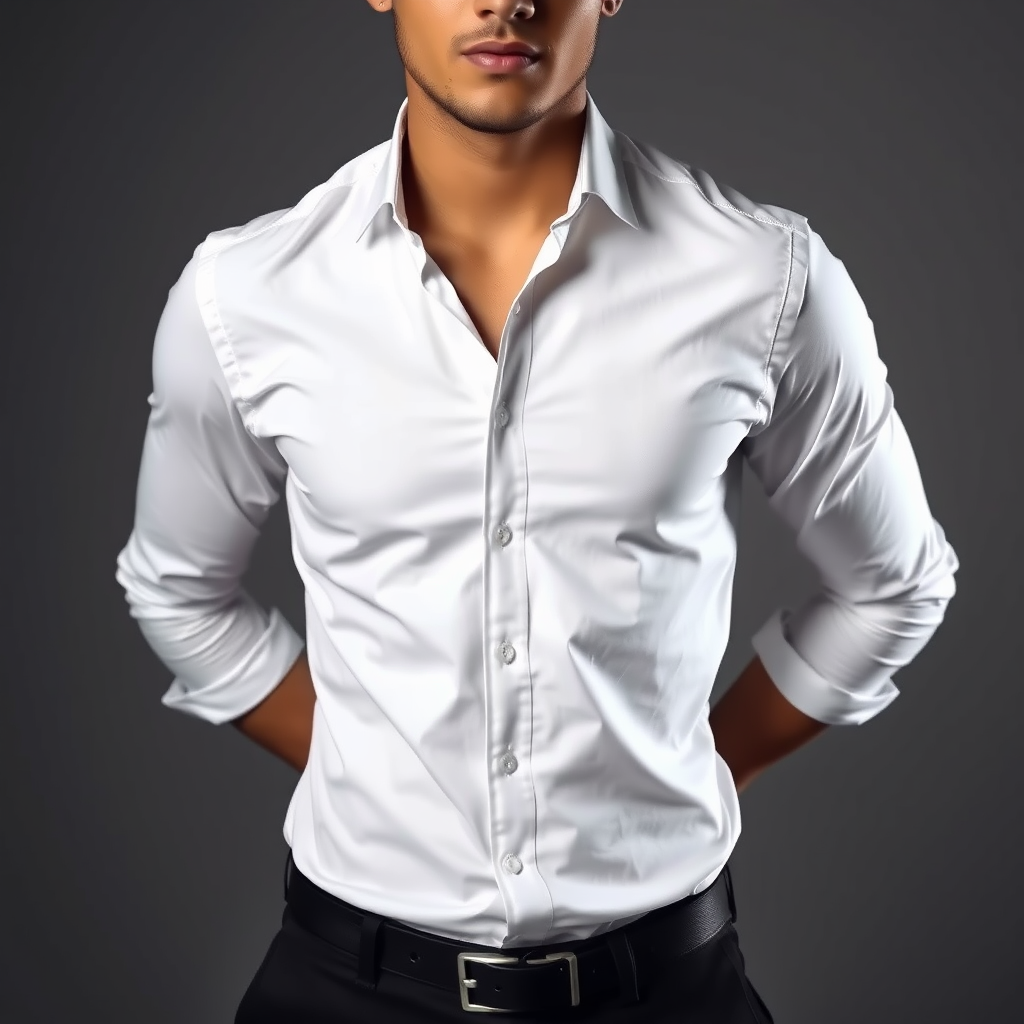

In [ ]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=HF_TOKEN,
)

prompt = "elegant white shirt, black trousers, formal outfit, studio lighting, full body, fashion photography"

imagen = client.text_to_image(
    prompt,
    model="black-forest-labs/FLUX.1-schnell",
)

imagen

## **Generando el outfit en el dueño del armario**

In [ ]:
!pip install -q gradio_client

Loaded as API: https://yisol-idm-vton.hf.space ✔
¡Outfit generado con éxito! Puedes ver el resultado aquí: /tmp/gradio/eba063347b06f481e8c2ec72720ca6e770b98fe83043b07a5da5d77c1fe734bd/image.png


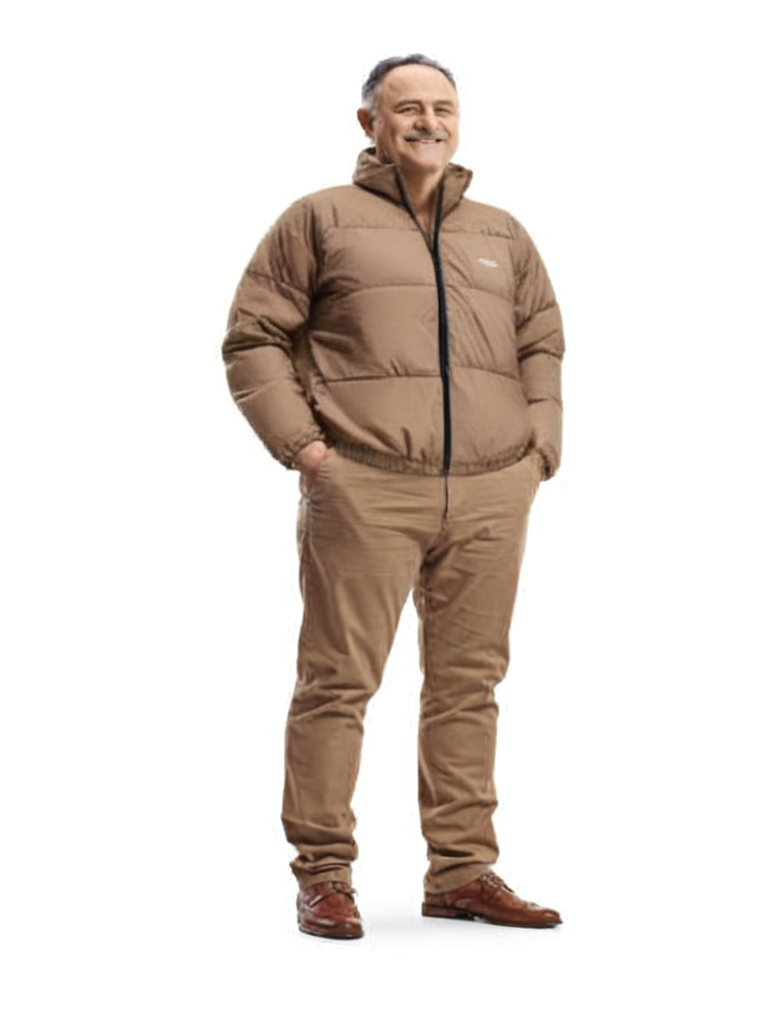

In [ ]:
from gradio_client import Client, handle_file

# Nos conectamos al servidor gratuito
client = Client("yisol/IDM-VTON")

# Aquí es donde ocurre la magia
result = client.predict(
    dict={"background":handle_file('/content/abuelillo prueba.jpg'), "layers":[], "composite":None},
    garm_img=handle_file('/content/chaqueton.jpg'), # Corregido: de .png a .jpg
    garment_des="Camiseta de mi armario", # Aquí puedes poner el nombre de la prenda
    is_checked=True,
    is_checked_crop=False,
    denoise_steps=30,
    seed=42,
    api_name="/tryon"
)

# El resultado es una tupla, la imagen suele ser el primer elemento
print(f"¡Outfit generado con éxito! Puedes ver el resultado aquí: {result[0]}")

# Para mostrarlo directamente en Colab:
from IPython.display import Image
Image(filename=result[0])

In [ ]:
from gradio_client import Client, handle_file
import time
from IPython.display import Image, display
import os

# 1. Conexión al motor de IA
client = Client("yisol/IDM-VTON")

def generar_outfit_completo(foto_persona, lista_prendas):
    imagen_actual = foto_persona

    for i, prenda in enumerate(lista_prendas):
        # Verificación de que el archivo existe localmente
        if not os.path.exists(prenda['path']):
            print(f"❌ Error: No se encuentra el archivo en {prenda['path']}")
            continue

        print(f"👕 Poniendo prenda {i+1}: {prenda['nombre']}...")

        try:
            # Llamada a la IA (Endpoint actualizado a /tryon)
            result = client.predict(
                dict={"background": handle_file(imagen_actual), "layers": [], "composite": None},
                garm_img=handle_file(prenda['path']),
                garment_des=prenda['nombre'],
                is_checked=True,
                is_checked_crop=False,
                denoise_steps=40, # Aumentado para mayor fidelidad a tu imagen
                seed=42,
                api_name="/tryon"
            )

            # La API devuelve [imagen_resultado, mascara]. Tomamos el índice 0.
            imagen_actual = result[0]
            print(f"✅ {prenda['nombre']} aplicada con éxito.")

            # Pausa para no saturar la API gratuita
            time.sleep(2)

        except Exception as e:
            print(f"⚠️ Hubo un problema con la prenda {prenda['nombre']}: {e}")

    return imagen_actual

# --- CONFIGURACIÓN DE RUTAS ---
# Ajusta estos nombres según los archivos que hayas subido a tu Colab
mi_persona = "/content/MANIQUI.jpg"

mis_prendas = [
    {'path': '/content/chaqueton.jpg', 'nombre': 'beige puffer jacket'},
    {'path': '/content/vermudas.jpg',  'nombre': 'grey chino shorts'},
    {'path': '/content/sandalias.jpg', 'nombre': 'dark green sandals'},
]
# --- EJECUCIÓN ---
try:
    print("🚀 Iniciando proceso de vestidor virtual...")
    resultado_final = generar_outfit_completo(mi_persona, mis_prendas)

    print("\n✨ ¡Outfit completo generado! ✨")
    display(Image(filename=resultado_final))

except Exception as e:
    print(f"❌ Error crítico en la ejecución: {e}")

Loaded as API: https://yisol-idm-vton.hf.space ✔


TooManyRequestsError: Too many requests to the API, please try again later.